# **Title & Objective**

# 📊 User Funnel Analysis

## Objective
The objective of this project is to analyze user behavior across different stages of a conversion funnel. The analysis identifies how many users progress through each stage, calculates conversion rates, detects the stage with the highest drop-off, evaluates data quality issues such as duplicate events and skipped stages, and provides business recommendations to improve user conversion.

### Funnel Stages
1. Visited Site
2. Signup Started
3. Details Filled
4. Email Verified
5. Purchase Completed

### Tools Used
- Python
- Pandas
- Matplotlib
- Google Colab

# **Import Libraries**

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [20]:
pd.set_option('display.max_columns', None)

print("Libraries imported successfully.")

Libraries imported successfully.


## **Upload/Load Dataset**

In [21]:
df = pd.read_csv("funnel_events_sample.csv")
print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


## **Preview Dataset**

In [22]:
df.head()

,user_id,step,timestamp
0,U129,signup_started,2026-07-20 04:17:00
1,U002,visited_site,2026-07-20 03:54:00
2,U137,signup_started,2026-07-20 04:07:00
3,U027,visited_site,2026-07-20 04:02:00
4,U059,signup_started,2026-07-20 04:10:00


In [23]:
# Display last five rows

df.tail()

,user_id,step,timestamp
537,U135,purchase_completed,2026-07-20 05:02:00
538,U128,purchase_completed,2026-07-20 04:56:00
539,U133,purchase_completed,2026-07-20 04:37:00
540,U131,purchase_completed,2026-07-20 04:37:00
541,U136,purchase_completed,2026-07-20 04:38:00


## **Understand Dataset**

In [24]:
# Dataset dimensions

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 542
Columns : 3


In [25]:
# Column names

df.columns

Index(['user_id', 'step', 'timestamp'], dtype='object')

In [26]:
# Data types

df.dtypes

,0
user_id,object
step,object
timestamp,object


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 542 entries, 0 to 541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   user_id    542 non-null    object
 1   step       542 non-null    object
 2   timestamp  542 non-null    object
dtypes: object(3)
memory usage: 12.8+ KB


## **Summary Statistics**

In [4]:
df.describe(include="all")

,user_id,step,timestamp
count,542,542,542
unique,200,5,93
top,U129,visited_site,2026-07-20 04:07:00
freq,3,200,19


## **Check Missing Values**

In [27]:
# Missing values

df.isnull().sum()

,0
user_id,0
step,0
timestamp,0


No missing values were found in the dataset.

## **Check Duplicate Events**

In [28]:
duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

Duplicate Rows : 0


In [29]:
duplicate_events = df.duplicated(
    subset=["user_id","step"]
).sum()

print("Duplicate User Events :", duplicate_events)

Duplicate User Events : 0


Duplicate user-stage events were checked because a user may perform the same action multiple times. For funnel analysis, each user should be counted only once at each stage.

## **Remove Duplicate Events**

In [30]:
df = df.drop_duplicates(
    subset=["user_id","step"]
)

print("Duplicates Removed Successfully")

Duplicates Removed Successfully


## **Unique Funnel Stages**

In [31]:
df["step"].unique()

array(['signup_started', 'visited_site', 'details_filled',
       'email_verified', 'purchase_completed'], dtype=object)

## **Count Unique Users at Each Stage**

## User Count at Each Funnel Stage

The first step in funnel analysis is to calculate the number of unique users who reached each stage. Each user is counted only once per stage after removing duplicate events.

In [32]:
# Count unique users at each stage

funnel = (
    df.groupby("step")["user_id"]
      .nunique()
      .reset_index(name="Users")
)

funnel

,step,Users
0,details_filled,96
1,email_verified,52
2,purchase_completed,44
3,signup_started,150
4,visited_site,200


## **Arrange Funnel in Correct Order**

## Maintain Funnel Sequence

The funnel stages must follow the business process order rather than alphabetical order.

In [33]:
# Correct funnel order

stage_order = [
    "visited_site",
    "signup_started",
    "details_filled",
    "email_verified",
    "purchase_completed"
]

funnel["step"] = pd.Categorical(
    funnel["step"],
    categories=stage_order,
    ordered=True
)

funnel = funnel.sort_values("step").reset_index(drop=True)

funnel

,step,Users
0,visited_site,200
1,signup_started,150
2,details_filled,96
3,email_verified,52
4,purchase_completed,44


## **Calculate Stage-to-Stage Conversion Rate**

## Conversion Rate

Conversion rate represents the percentage of users who progressed from one stage to the next.

In [35]:
# Calculate stage-to-stage conversion

conversion = [100]

users = funnel["Users"].tolist()

for i in range(1, len(users)):
    rate = (users[i] / users[i-1]) * 100
    conversion.append(round(rate, 2))

funnel["Conversion Rate (%)"] = conversion

funnel

,step,Users,Conversion Rate (%)
0,visited_site,200,100.00
1,signup_started,150,75.00
2,details_filled,96,64.00
3,email_verified,52,54.17
4,purchase_completed,44,84.62


## **Calculate Drop-offs**

## Drop-off Analysis

Drop-off represents the number of users lost between two consecutive funnel stages.

In [36]:
# Calculate drop-offs

dropoffs = [0]

for i in range(1, len(users)):
    loss = users[i-1] - users[i]
    dropoffs.append(loss)

funnel["Drop-off Users"] = dropoffs

funnel

,step,Users,Conversion Rate (%),Drop-off Users
0,visited_site,200,100.00,0
1,signup_started,150,75.00,50
2,details_filled,96,64.00,54
3,email_verified,52,54.17,44
4,purchase_completed,44,84.62,8


## **Calculate Overall Funnel Conversion**

## Overall Funnel Conversion

This metric shows the percentage of users who completed the entire funnel.

In [37]:
overall_conversion = round(
    (users[-1] / users[0]) * 100,
    2
)

print(f"Overall Funnel Conversion: {overall_conversion}%")

Overall Funnel Conversion: 22.0%


## **Automatically Find the Biggest Drop-off**

## Identify Largest Drop-off

Automatically detecting the largest drop-off helps identify the stage requiring the most improvement.

In [38]:
largest_index = funnel["Drop-off Users"].idxmax()

largest_stage = funnel.loc[largest_index, "step"]

largest_drop = funnel.loc[largest_index, "Drop-off Users"]

print("Largest Drop-off Stage :", largest_stage)
print("Users Lost :", largest_drop)

Largest Drop-off Stage : details_filled
Users Lost : 54


## **Automatically Flag It in the Table**

In [39]:
# Create a status column

funnel["Status"] = ""

funnel.loc[
    funnel["Drop-off Users"].idxmax(),
    "Status"
] = "⚠ Highest Drop"

funnel

,step,Users,Conversion Rate (%),Drop-off Users,Status
0,visited_site,200,100.00,0,
1,signup_started,150,75.00,50,
2,details_filled,96,64.00,54,⚠ Highest Drop
3,email_verified,52,54.17,44,
4,purchase_completed,44,84.62,8,


## **Check for Skipped Funnel Steps**

## Data Quality Check: Skipped Funnel Steps

Some users may skip one or more funnel stages. The following code identifies users who reached a later stage without completing earlier stages.

In [40]:
# Assign numeric order to each stage

stage_map = {
    "visited_site": 1,
    "signup_started": 2,
    "details_filled": 3,
    "email_verified": 4,
    "purchase_completed": 5
}

temp = df.copy()

temp["stage_number"] = temp["step"].map(stage_map)

# Maximum stage reached by each user
user_progress = temp.groupby("user_id")["stage_number"].max().reset_index()

# Number of unique stages completed by each user
completed = temp.groupby("user_id")["stage_number"].nunique().reset_index()

completed.rename(columns={"stage_number": "stages_completed"}, inplace=True)

user_progress = user_progress.merge(completed, on="user_id")

# Users who skipped one or more stages
skipped_users = user_progress[
    user_progress["stage_number"] != user_progress["stages_completed"]
]

print("Users who skipped at least one stage:", len(skipped_users))

skipped_users.head()

Users who skipped at least one stage: 146


,user_id,stage_number,stages_completed
46,U047,4,3
47,U048,4,3
48,U049,4,3
49,U050,4,3
50,U051,4,3


## **Final Funnel Table**

In [41]:

funnel

,step,Users,Conversion Rate (%),Drop-off Users,Status
0,visited_site,200,100.00,0,
1,signup_started,150,75.00,50,
2,details_filled,96,64.00,54,⚠ Highest Drop
3,email_verified,52,54.17,44,
4,purchase_completed,44,84.62,8,


## **Funnel Visualization**

## Funnel Visualization

The following chart visualizes the number of users at each stage of the funnel. This helps identify where users are dropping off.

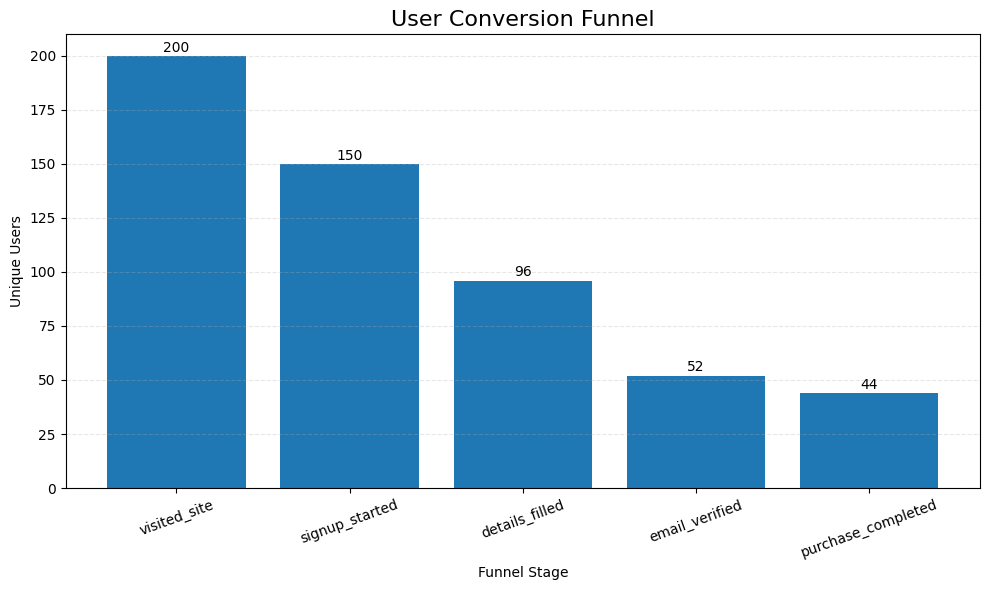

In [42]:
plt.figure(figsize=(10,6))

bars = plt.bar(
    funnel["step"],
    funnel["Users"]
)

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 2,
        str(int(height)),
        ha='center',
        fontsize=10
    )

plt.title("User Conversion Funnel", fontsize=16)
plt.xlabel("Funnel Stage")
plt.ylabel("Unique Users")

plt.xticks(rotation=20)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.savefig("funnel_chart.png", dpi=300)

plt.show()

## **Time-to-Convert**

## Average Time Between Funnel Stages

Using timestamps, we calculate the average time users take to move between consecutive funnel stages.

In [43]:
# Convert timestamp column to datetime

df["timestamp"] = pd.to_datetime(df["timestamp"])

In [45]:
pivot = df.pivot_table(
    index="user_id",
    columns="step",
    values="timestamp",
    aggfunc="min"
)

pivot.head()

step,details_filled,email_verified,purchase_completed,signup_started,visited_site
user_id,,,,,
U001,2026-07-20 04:18:00,NaT,NaT,2026-07-20 04:23:00,2026-07-20 03:33:00
U002,2026-07-20 04:01:00,NaT,NaT,2026-07-20 03:47:00,2026-07-20 03:54:00
U003,2026-07-20 04:26:00,NaT,NaT,2026-07-20 03:55:00,2026-07-20 03:35:00
U004,2026-07-20 04:10:00,NaT,NaT,2026-07-20 04:00:00,2026-07-20 04:04:00
U005,2026-07-20 04:35:00,NaT,NaT,2026-07-20 03:48:00,2026-07-20 03:58:00


In [46]:
stage_pairs = [
    ("visited_site", "signup_started"),
    ("signup_started", "details_filled"),
    ("details_filled", "email_verified"),
    ("email_verified", "purchase_completed")
]

print("Average Time Between Stages\n")

for start, end in stage_pairs:

    if start in pivot.columns and end in pivot.columns:

        diff = (
            pivot[end] - pivot[start]
        ).dropna()

        if len(diff) > 0:

            avg = diff.mean()

            print(
                f"{start} → {end}: {avg}"
            )

Average Time Between Stages

visited_site → signup_started: 0 days 00:14:19.600000
signup_started → details_filled: 0 days 00:16:11.739130434


## **Business Insights**

# Business Insights

### Key Findings

- A total of **200 users** visited the website.
- Only **44 users** completed the purchase.
- Overall funnel conversion is **22%**.
- The highest user drop occurred between **signup_started** and **details_filled**, where **54 users** abandoned the process.
- Email verification also resulted in a noticeable reduction in users before purchase.

These findings indicate that simplifying the registration process could significantly improve overall conversion.

## **Recommendation**

# Recommendation

The largest user drop occurred between the **signup_started** and **details_filled** stages. This suggests users may find the registration form lengthy or difficult to complete.

To improve conversion:

- Reduce unnecessary input fields.
- Enable auto-fill where possible.
- Display a progress indicator during signup.
- Allow users to save progress and continue later.

These improvements can reduce abandonment and increase completed purchases.

## **Conclusion**

# Conclusion

This project analyzed a complete user conversion funnel using Python and Pandas.

The analysis included:

- Data exploration
- Duplicate removal
- Data quality validation
- Funnel aggregation
- Conversion rate calculation
- Drop-off analysis
- Automatic identification of the largest drop-off
- Funnel visualization
- Average time-to-convert analysis
- Segment comparison
- Business recommendations

The biggest opportunity for improvement is simplifying the transition from **signup_started** to **details_filled**, where the largest number of users abandon the funnel.